In [1]:
## conda activate gpy_torch_env
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import tqdm
import torch 
from torch.autograd.functional import jacobian
from torch.distributions.multivariate_normal import MultivariateNormal
import gpytorch
import pyro
from pyro.infer import MCMC, NUTS
import pyro.distributions as dist
from scipy.linalg import eigh
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.stats import norm, multivariate_normal, invgamma, uniform
from scipy import interpolate
import pickle



c:\Users\mjcol\miniconda3\envs\uq_disc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
def time_dependent_prediction_metrics(
    y_pred_samples,
    y_true,
    credibility_level=0.95
):
    """
    Compute RMSE, bias, empirical coverage, and interval width
    for time-dependent posterior predictive samples.

    Parameters
    ----------
    y_pred_samples : array-like
        Posterior predictive samples with shape:
            (n_samples, n_times)
        or
            (n_experiments, n_samples, n_times)

    y_true : array-like
        True model output with shape:
            (n_times,)
        or
            (n_experiments, n_times)

    credibility_level : float
        Credible/prediction interval level. Default is 0.95.

    Returns
    -------
    metrics : dict
        Dictionary of time-dependent and time-averaged metrics.
    """

    y_pred_samples = np.asarray(y_pred_samples)
    y_true = np.asarray(y_true)

    alpha = 1.0 - credibility_level
    lower_q = 100 * alpha / 2
    upper_q = 100 * (1 - alpha / 2)

    # Case 1: one experiment
    # y_pred_samples shape: (n_samples, n_times)
    if y_pred_samples.ndim == 2:
        pred_mean = np.mean(y_pred_samples, axis=0)

        lower = np.percentile(y_pred_samples, lower_q, axis=0)
        upper = np.percentile(y_pred_samples, upper_q, axis=0)

        error = pred_mean - y_true

        bias_t = error
        rmse_t = np.sqrt(error**2)

        coverage_t = ((y_true >= lower) & (y_true <= upper)).astype(float)
        width_t = upper - lower

        return {
            "prediction_mean": pred_mean,
            "lower_bound": lower,
            "upper_bound": upper,

            "bias_time": bias_t,
            "rmse_time": rmse_t,
            "coverage_time": coverage_t,
            "interval_width_time": width_t,

            "mean_bias_over_time": np.mean(bias_t),
            "mean_rmse_over_time": np.mean(rmse_t),
            "mean_coverage_over_time": np.mean(coverage_t),
            "mean_interval_width_over_time": np.mean(width_t),
        }

    # Case 2: repeated experiments
    # y_pred_samples shape: (n_experiments, n_samples, n_times)
    elif y_pred_samples.ndim == 3:
        pred_mean = np.mean(y_pred_samples, axis=1)

        lower = np.percentile(y_pred_samples, lower_q, axis=1)
        upper = np.percentile(y_pred_samples, upper_q, axis=1)

        error = pred_mean - y_true

        bias_t = np.mean(error, axis=0)
        rmse_t = np.sqrt(np.mean(error**2, axis=0))

        coverage_t = np.mean(
            (y_true >= lower) & (y_true <= upper),
            axis=0
        )

        width_t = np.mean(upper - lower, axis=0)

        return {
            "prediction_mean": pred_mean,
            "lower_bound": lower,
            "upper_bound": upper,

            "bias_time": bias_t,
            "rmse_time": rmse_t,
            "empirical_coverage_time": coverage_t,
            "mean_interval_width_time": width_t,

            "mean_bias_over_time": np.mean(bias_t),
            "mean_rmse_over_time": np.mean(rmse_t),
            "mean_coverage_over_time": np.mean(coverage_t),
            "mean_interval_width_over_time": np.mean(width_t),
        }

    else:
        raise ValueError(
            "y_pred_samples must have shape "
            "(n_samples, n_times) or "
            "(n_experiments, n_samples, n_times)"
        )

In [22]:
def computeJitter(Cmat, target_min_eigval, min_jitter):
    eigvals = torch.linalg.eigvalsh(Cmat)
    lambda_min = eigvals.min()
    required_jitter = torch.clamp(target_min_eigval - lambda_min, min=min_jitter).item()
    return required_jitter  

class MultivariateOrthogonalKernel(torch.nn.Module):
    def __init__(self, C_func, num_par, call_model, call_jac, gamma=1e-1, min_jitter=1e-8, max_tries=6):
        super().__init__()
        self.J = C_func.num_tasks
        self.C_func = C_func
        self.num_par = num_par
        self.fmodel = call_model
        self.jac    = call_jac
        self.gamma = gamma
        self.min_jitter = min_jitter
        self.max_tries = max_tries

    def forward(self, x, theta, xvol=None, return_lazy=True):
        n = x.shape[0]
        if xvol is None:
            xvol = 1.0 / n

        # m = n * J output dimension
        m = n * self.J
        
        # 1) Lazy covariance C: (m, m)
        C = self.gamma * self.C_func(x)  # keep lazy

        # 2) Jacobian Jmat: (m, P)
        J_theta_x = self.jac(theta, x)  # (n, J, P)
        # Jmat = J_theta_x.reshape(m, -1)
        # FROM GPT
        Jmat = J_theta_x.reshape(m, self.num_par)

        # 3) CJ and H
        CJ = C @ Jmat                          # (m, P)

     
        
        H = (xvol * xvol) * (Jmat.T @ CJ)      # (P, P)

        P = H.shape[0]
        I_P = torch.eye(P, device=H.device, dtype=H.dtype)

        # 4) Cholesky with escalating jitter
        jitter = self.min_jitter
        for _ in range(self.max_tries):
            try:
                L = torch.linalg.cholesky(H + jitter * I_P)
                break
            except RuntimeError:
                jitter *= 10.0
        else:
            raise RuntimeError("Failed to Cholesky-factor H even after jitter escalation.")

        # 5) Projection term: (xvol*CJ) H^{-1} (xvol*CJ)^T
        h = xvol * CJ                          # (m, P)
        X = torch.cholesky_solve(h.T, L)       # (P, m)
        proj = h @ X                           # (m, m)

        # 6) C_delta = C - proj
        C_delta = C - proj

        if return_lazy and hasattr(C_delta, "to_dense"):
            # print('lazy')
            return C_delta

        # If you need dense
        if hasattr(C_delta, "to_dense"):
            C_delta = C_delta.to_dense()
            # print('dense')
        C_delta = 0.5 * (C_delta + C_delta.T)
        return C_delta

In [23]:
## Spring Problem
num_par = 8 #leave off discrepancy hyperparameters
J = 4
burnin = 5000
from Four_Spring_Model import call_model as call_model_4spring
from Run_FourSpring_AMwithGibbs_50signals import compute_jacobian as jac_4spring

marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.raw_lengthscale.requires_grad = False
target_min_eigval = 1e-6
min_jitter = 1e-10 
gamma_true=1.0

GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(0.1))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False



for i in [16]:
    if i<10:
        # fname = 'Fitz_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'FourSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'FourSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    F_true = data['force_true']
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    

    samples_IND = chain_IND_all[0,:,burnin:]
    samples_MOP = chain_MOP_all[0,:,burnin:]
    s2_IND      = s2chain_IND_all[:,burnin:].flatten()
    s2_MOP      = s2chain_MOP_all[:,burnin:].flatten()
    
    num_draws = min(300, samples_IND[0,:].shape[0])
    idx = torch.randint(0, samples_IND[0,:].shape[0], (num_draws,))

    posterior_state_IND = []
    posterior_state_MOP = []
    posterior_state_IND_disc = []
    posterior_state_MOP_disc = []
    disc_IND = []
    disc_MOP = []
    I_MV = torch.eye(n_grid * J)

    GP_Cov_MOP = MultivariateOrthogonalKernel(GP_Cov_unc, num_par=8,call_model=call_model_4spring, 
                                               call_jac=lambda theta,t: jac_4spring(theta,t,F_true), gamma=gamma_true, 
                                                    min_jitter=min_jitter)

    for ii in idx:
        states_IND = call_model_4spring(samples_IND[:num_par,ii].flatten(),tvals,F_true)
        posterior_state_IND.append(states_IND[0:J,:])
        states_MOP = call_model_4spring(samples_MOP[:num_par,ii].flatten(),tvals,F_true)
        posterior_state_MOP.append(states_MOP[0:J,:])

        

        ## IND
        GP_Cov_unc.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_IND[num_par+1,ii]]))
        C_x_IND = samples_IND[num_par,ii]*GP_Cov_unc(tvals).evaluate() #+ s2_IND[ii]*torch.eye(n_grid*J)
        jitter = computeJitter(C_x_IND, target_min_eigval, min_jitter)
        C_x_IND = C_x_IND + jitter*torch.eye(n_grid*J)
        L = torch.linalg.cholesky(C_x_IND + jitter * I_MV)
        temp_IND = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
        disc_IND.append(temp_IND.T)


        ## MOP
        GP_Cov_MOP.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_MOP[num_par+1,ii]]))
        GP_Cov_MOP.gamma = samples_MOP[num_par,ii]
        C_delta_theta_true_xobs_flat = GP_Cov_MOP(tvals, samples_MOP[:num_par,ii].flatten()) #+ s2_MOP[ii]*torch.eye(n_grid*J)
        jitter = computeJitter(C_delta_theta_true_xobs_flat, target_min_eigval, min_jitter)
        L = torch.linalg.cholesky(C_delta_theta_true_xobs_flat + jitter * I_MV)
        temp_MOP = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
        disc_MOP.append(temp_MOP.T)

        posterior_state_IND_disc.append(states_IND[0:J,:]+temp_IND.T+torch.rand((J,n_grid))*s2_IND[ii])
        posterior_state_MOP_disc.append(states_MOP[0:J,:]+temp_MOP.T+torch.rand((J,n_grid))*s2_MOP[ii])


    posterior_state_IND = torch.stack(posterior_state_IND)
    posterior_state_MOP = torch.stack(posterior_state_MOP)
    disc_IND = torch.stack(disc_IND)
    disc_MOP = torch.stack(disc_MOP)

    posterior_state_IND_disc = torch.stack(posterior_state_IND_disc)
    posterior_state_MOP_disc = torch.stack(posterior_state_MOP_disc)



    x_mean_IND = posterior_state_IND.mean(dim=0)
    x_lower_IND = posterior_state_IND.quantile(0.05, dim=0)
    x_upper_IND = posterior_state_IND.quantile(0.95, dim=0)

    x_mean_MOP = posterior_state_MOP.mean(dim=0)
    x_lower_MOP = posterior_state_MOP.quantile(0.05, dim=0)
    x_upper_MOP = posterior_state_MOP.quantile(0.95, dim=0)

    x_mean_IND_disc = posterior_state_IND_disc.mean(dim=0)
    x_lower_IND_disc = posterior_state_IND_disc.quantile(0.05, dim=0)
    x_upper_IND_disc = posterior_state_IND_disc.quantile(0.95, dim=0)

    x_mean_MOP_disc = posterior_state_MOP_disc.mean(dim=0)
    x_lower_MOP_disc = posterior_state_MOP_disc.quantile(0.05, dim=0)
    x_upper_MOP_disc = posterior_state_MOP_disc.quantile(0.95, dim=0)


    ###############################
    



c:\Users\mjcol\miniconda3\envs\uq_disc\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
c:\Users\mjcol\miniconda3\envs\uq_disc\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


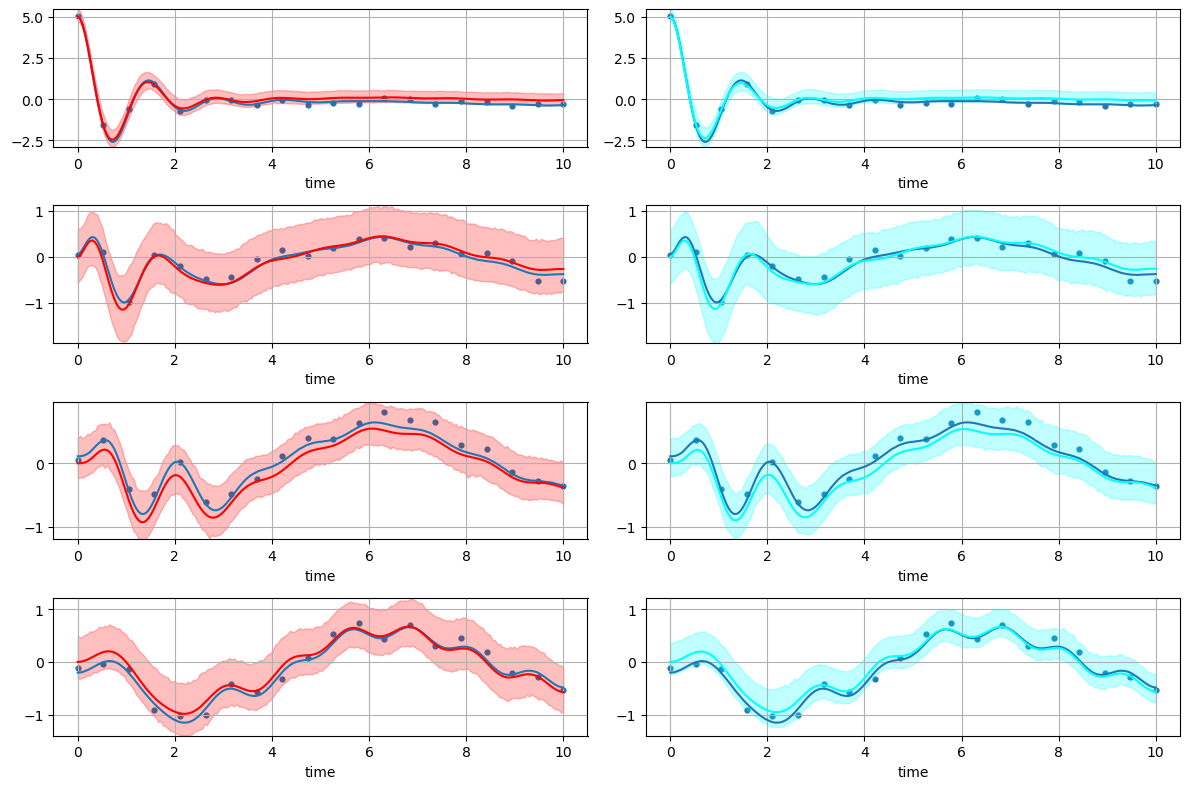

In [24]:
plt.figure(figsize=(12, 8))
for iii in range(4):
    y_upper = np.max((np.max(x_upper_IND_disc[iii,:].detach().numpy().flatten()),np.max(x_upper_MOP_disc[iii,:].detach().numpy().flatten())))
    y_lower = np.min((np.min(x_lower_IND_disc[iii,:].detach().numpy().flatten()),np.min(x_lower_MOP_disc[iii,:].detach().numpy().flatten())))
    
    plt.subplot(4,2,(iii)*2+1)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_IND[iii,:], label="IND mean",color='red')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_IND_disc[iii,:].detach().numpy(),
        x_upper_IND_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='red',
        label="90% posterior band",
    )
    plt.xlabel("time")
    # plt.ylabel("displacement")
    # plt.legend()
    plt.ylim((y_lower,y_upper))
    plt.grid()
    plt.tight_layout()

    plt.subplot(4,2,(iii)*2+2)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_MOP[iii,:], label="MOP mean",color='cyan')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_MOP_disc[iii,:].detach().numpy(),
        x_upper_MOP_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='cyan',
        label="90% posterior band",
    )
    plt.xlabel("time")
    # plt.ylabel("displacement")
    # plt.legend()
    plt.ylim((y_lower,y_upper))
    plt.tight_layout()
    plt.grid()
plt.show()


In [ ]:
for i in range(4):
    # For forward model evals WITHOUT DISCREPANCY INCLUDED
    IND_metrics = time_dependent_prediction_metrics(
        posterior_state_IND[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )

    MOP_metrics = time_dependent_prediction_metrics(
        posterior_state_MOP[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )
    # For model evals WITH DISCREPANCY ADDED TO OUTPUT
    # IND_metrics = time_dependent_prediction_metrics(
    #     posterior_state_IND_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )

    # MOP_metrics = time_dependent_prediction_metrics(
    #     posterior_state_MOP_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )
    print(f"OUTPUT {i}\n")
    print("Mean RMSE over time:", IND_metrics["mean_rmse_over_time"],MOP_metrics["mean_rmse_over_time"])
    print("Mean bias over time:", IND_metrics["mean_bias_over_time"], MOP_metrics["mean_bias_over_time"])
    print("Mean coverage over time:", IND_metrics["mean_coverage_over_time"], MOP_metrics["mean_coverage_over_time"])
    print("Mean interval width over time:", IND_metrics["mean_interval_width_over_time"], MOP_metrics["mean_interval_width_over_time"])

In [25]:
## Spring Problem
num_par = 4 #leave off discrepancy hyperparameters
J = 2
burnin = 5000
from Run_TwoSpring_AMwithGibbs_50signals import call_model as call_model_2spring
from Run_TwoSpring_AMwithGibbs_50signals import compute_jacobian as jac_2spring

marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.raw_lengthscale.requires_grad = False
target_min_eigval = 1e-6
min_jitter = 1e-10 
gamma_true=1.0

GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(0.1))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False



for i in [12]:
    if i<10:
        # fname = 'Fitz_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'TwoSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'TwoSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    F_true = data['force_true']
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    

    samples_IND = chain_IND_all[0,:,burnin:]
    samples_MOP = chain_MOP_all[0,:,burnin:]
    s2_IND      = s2chain_IND_all[:,burnin:].flatten()
    s2_MOP      = s2chain_MOP_all[:,burnin:].flatten()
    
    num_draws = min(300, samples_IND[0,:].shape[0])
    idx = torch.randint(0, samples_IND[0,:].shape[0], (num_draws,))

    posterior_state_IND = []
    posterior_state_MOP = []
    posterior_state_IND_disc = []
    posterior_state_MOP_disc = []
    disc_IND = []
    disc_MOP = []
    I_MV = torch.eye(n_grid * J)

    GP_Cov_MOP = MultivariateOrthogonalKernel(GP_Cov_unc, num_par=num_par,call_model=call_model_2spring, 
                                               call_jac=lambda theta,t: jac_2spring(theta,t,F_true), gamma=gamma_true, 
                                                    min_jitter=min_jitter)

    for ii in idx:
        states_IND = call_model_2spring(samples_IND[:num_par,ii].flatten(),tvals,F_true)
        posterior_state_IND.append(states_IND[0:J,:])
        states_MOP = call_model_2spring(samples_MOP[:num_par,ii].flatten(),tvals,F_true)
        posterior_state_MOP.append(states_MOP[0:J,:])

        

        ## IND
        GP_Cov_unc.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_IND[num_par+1,ii]]))
        C_x_IND = samples_IND[num_par,ii]*GP_Cov_unc(tvals).evaluate() #+ s2_IND[ii]*torch.eye(n_grid*J)
        jitter = computeJitter(C_x_IND, target_min_eigval, min_jitter)
        C_x_IND = C_x_IND + jitter*torch.eye(n_grid*J)
        L = torch.linalg.cholesky(C_x_IND + jitter * I_MV)
        temp_IND = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
        disc_IND.append(temp_IND.T)


        ## MOP
        GP_Cov_MOP.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_MOP[num_par+1,ii]]))
        GP_Cov_MOP.gamma = samples_MOP[num_par,ii]
        C_delta_theta_true_xobs_flat = GP_Cov_MOP(tvals, samples_MOP[:num_par,ii].flatten()) #+ s2_MOP[ii]*torch.eye(n_grid*J)
        jitter = computeJitter(C_delta_theta_true_xobs_flat, target_min_eigval, min_jitter)
        L = torch.linalg.cholesky(C_delta_theta_true_xobs_flat + jitter * I_MV)
        temp_MOP = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
        disc_MOP.append(temp_MOP.T)

        posterior_state_IND_disc.append(states_IND[0:J,:]+temp_IND.T+torch.rand((J,n_grid))*s2_IND[ii])
        posterior_state_MOP_disc.append(states_MOP[0:J,:]+temp_MOP.T+torch.rand((J,n_grid))*s2_MOP[ii])



    posterior_state_IND = torch.stack(posterior_state_IND)
    posterior_state_MOP = torch.stack(posterior_state_MOP)
    disc_IND = torch.stack(disc_IND)
    disc_MOP = torch.stack(disc_MOP)

    posterior_state_IND_disc = torch.stack(posterior_state_IND_disc)
    posterior_state_MOP_disc = torch.stack(posterior_state_MOP_disc)



    x_mean_IND = posterior_state_IND.mean(dim=0)
    x_lower_IND = posterior_state_IND.quantile(0.05, dim=0)
    x_upper_IND = posterior_state_IND.quantile(0.95, dim=0)

    x_mean_MOP = posterior_state_MOP.mean(dim=0)
    x_lower_MOP = posterior_state_MOP.quantile(0.05, dim=0)
    x_upper_MOP = posterior_state_MOP.quantile(0.95, dim=0)

    x_mean_IND_disc = posterior_state_IND_disc.mean(dim=0)
    x_lower_IND_disc = posterior_state_IND_disc.quantile(0.05, dim=0)
    x_upper_IND_disc = posterior_state_IND_disc.quantile(0.95, dim=0)

    x_mean_MOP_disc = posterior_state_MOP_disc.mean(dim=0)
    x_lower_MOP_disc = posterior_state_MOP_disc.quantile(0.05, dim=0)
    x_upper_MOP_disc = posterior_state_MOP_disc.quantile(0.95, dim=0)


    




c:\Users\mjcol\miniconda3\envs\uq_disc\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
c:\Users\mjcol\miniconda3\envs\uq_disc\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(
c:\Users\mjcol\miniconda3\envs\uq_disc\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-04 to the diagonal
  warnings.warn(


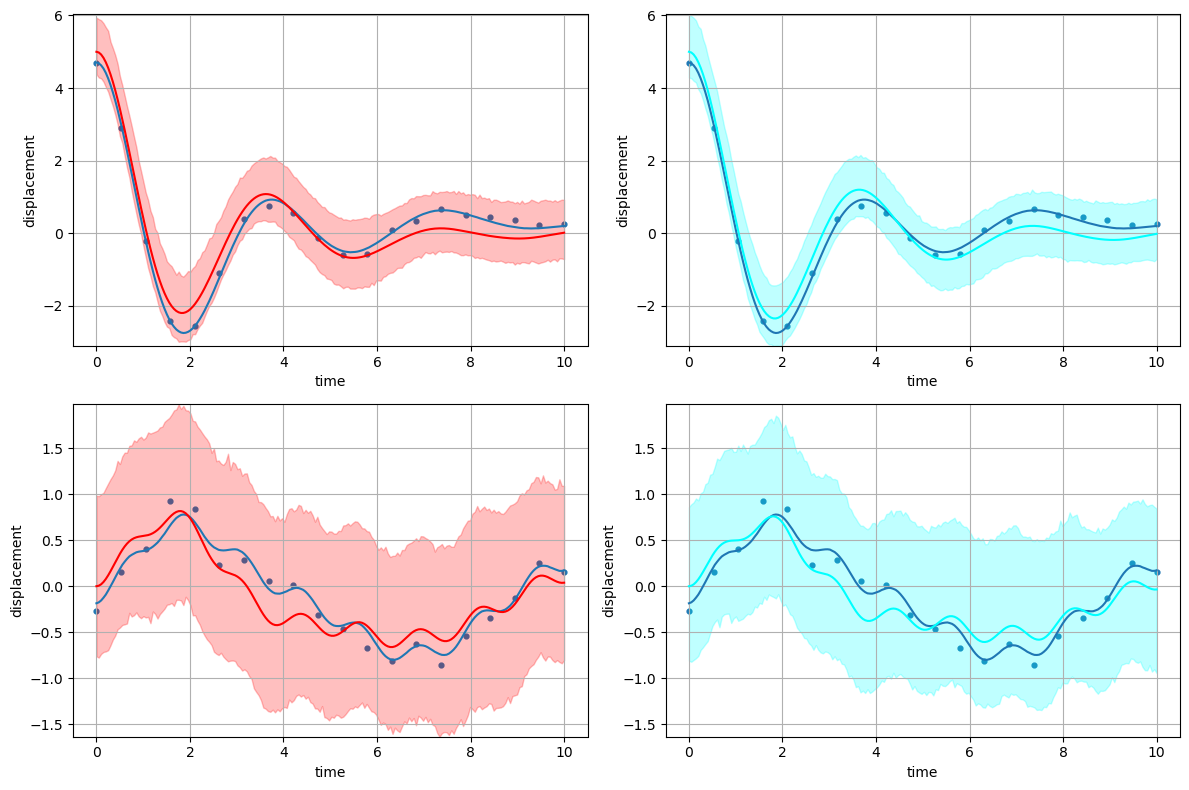

In [26]:
###############################
# Plot is without discrepancy added
plt.figure(figsize=(12, 8))
for iii in range(J):
    y_upper = np.max((np.max(x_upper_IND_disc[iii,:].detach().numpy().flatten()),np.max(x_upper_MOP_disc[iii,:].detach().numpy().flatten())))
    y_lower = np.min((np.min(x_lower_IND_disc[iii,:].detach().numpy().flatten()),np.min(x_lower_MOP_disc[iii,:].detach().numpy().flatten())))
    
    plt.subplot(J,2,(iii)*2+1)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_IND[iii,:], label="IND mean",color='red')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_IND_disc[iii,:].detach().numpy(),
        x_upper_IND_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='red',
        label="90% posterior band",
    )
    plt.xlabel("time")
    plt.ylabel("displacement")
    # plt.legend()
    plt.ylim((y_lower,y_upper))
    plt.grid()
    plt.tight_layout()

    plt.subplot(J,2,(iii)*2+2)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_MOP[iii,:], label="MOP mean",color='cyan')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_MOP_disc[iii,:].detach().numpy(),
        x_upper_MOP_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='cyan',
        label="90% posterior band",
    )
    plt.xlabel("time")
    plt.ylabel("displacement")
    # plt.legend()
    plt.ylim((y_lower,y_upper))
    plt.grid()
    plt.tight_layout()
plt.show()

In [ ]:
for i in range(J):
    # For forward model evals WITHOUT DISCREPANCY INCLUDED
    IND_metrics = time_dependent_prediction_metrics(
        posterior_state_IND[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )

    MOP_metrics = time_dependent_prediction_metrics(
        posterior_state_MOP[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )
    # For model evals WITH DISCREPANCY ADDED TO OUTPUT
    # IND_metrics = time_dependent_prediction_metrics(
    #     posterior_state_IND_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )

    # MOP_metrics = time_dependent_prediction_metrics(
    #     posterior_state_MOP_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )
    print(f"OUTPUT {i}\n")
    print("Mean RMSE over time:", IND_metrics["mean_rmse_over_time"],MOP_metrics["mean_rmse_over_time"])
    print("Mean bias over time:", IND_metrics["mean_bias_over_time"], MOP_metrics["mean_bias_over_time"])
    print("Mean coverage over time:", IND_metrics["mean_coverage_over_time"], MOP_metrics["mean_coverage_over_time"])
    print("Mean interval width over time:", IND_metrics["mean_interval_width_over_time"], MOP_metrics["mean_interval_width_over_time"])

In [27]:
## Spring Problem
num_par = 5 #leave off discrepancy hyperparameters
J = 3
burnin = 5000
from Run_SIRV_IRV_AMwithGibbs_50signals import call_model as call_model_IRV
from Run_SIRV_IRV_AMwithGibbs_50signals import compute_jacobian as jac_IRV

marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.raw_lengthscale.requires_grad = False
target_min_eigval = 1e-6
min_jitter = 1e-10 
gamma_true=1.0

GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(0.1))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False

# Helper function since IRV model gives back all four states, we just need the last three
def IRV_only(params,x):
    all_out = call_model_IRV(params,x)
    return all_out[1:4,:]



for i in [7]:
    if i<10:
        # fname = 'Fitz_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'SIRV_IRV_50signal_results_V2/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'SIRV_IRV_50signal_results_V2/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    

    samples_IND = chain_IND_all[0,:,burnin:]
    samples_MOP = chain_MOP_all[0,:,burnin:]
    s2_IND      = s2chain_IND_all[:,burnin:].flatten()
    s2_MOP      = s2chain_MOP_all[:,burnin:].flatten()
    
    num_draws = min(300, samples_IND[0,:].shape[0])
    idx = torch.randint(0, samples_IND[0,:].shape[0], (num_draws,))

    posterior_state_IND = []
    posterior_state_MOP = []
    posterior_state_IND_disc = []
    posterior_state_MOP_disc = []
    disc_IND = []
    disc_MOP = []
    I_MV = torch.eye(n_grid * J)

    GP_Cov_MOP = MultivariateOrthogonalKernel(GP_Cov_unc, num_par=num_par,call_model=IRV_only, 
                                               call_jac=jac_IRV, gamma=gamma_true, 
                                                    min_jitter=min_jitter)

    for ii in idx:
        states_IND = call_model_IRV(samples_IND[:num_par,ii].flatten(),tvals)
        posterior_state_IND.append(states_IND[1:4,:])
        states_MOP = call_model_IRV(samples_MOP[:num_par,ii].flatten(),tvals)
        posterior_state_MOP.append(states_MOP[1:4,:])

        

        ## IND
        GP_Cov_unc.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_IND[num_par+1,ii]]))
        C_x_IND = samples_IND[num_par,ii]*GP_Cov_unc(tvals).evaluate() + s2_IND[ii]*torch.eye(n_grid*J)
        jitter = computeJitter(C_x_IND, target_min_eigval, min_jitter)
        C_x_IND = C_x_IND + jitter*torch.eye(n_grid*J)
        L = torch.linalg.cholesky(C_x_IND + jitter * I_MV)
        temp_IND = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
        disc_IND.append(temp_IND.T)


        ## MOP
        GP_Cov_MOP.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_MOP[num_par+1,ii]]))
        GP_Cov_MOP.gamma = samples_MOP[num_par,ii]
        C_delta_theta_true_xobs_flat = GP_Cov_MOP(tvals, samples_MOP[:num_par,ii].flatten()) + s2_MOP[ii]*torch.eye(n_grid*J)
        jitter = computeJitter(C_delta_theta_true_xobs_flat, target_min_eigval, min_jitter)
        L = torch.linalg.cholesky(C_delta_theta_true_xobs_flat + jitter * I_MV)
        temp_MOP = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
        disc_MOP.append(temp_MOP.T)

        posterior_state_IND_disc.append(states_IND[1:4,:]+temp_IND.T+torch.rand((J,n_grid))*s2_IND[ii])
        posterior_state_MOP_disc.append(states_MOP[1:4,:]+temp_MOP.T+torch.rand((J,n_grid))*s2_MOP[ii])



    posterior_state_IND = torch.stack(posterior_state_IND)
    posterior_state_MOP = torch.stack(posterior_state_MOP)
    disc_IND = torch.stack(disc_IND)
    disc_MOP = torch.stack(disc_MOP)

    posterior_state_IND_disc = torch.stack(posterior_state_IND_disc)
    posterior_state_MOP_disc = torch.stack(posterior_state_MOP_disc)



    x_mean_IND = posterior_state_IND.mean(dim=0)
    x_lower_IND = posterior_state_IND.quantile(0.05, dim=0)
    x_upper_IND = posterior_state_IND.quantile(0.95, dim=0)

    x_mean_MOP = posterior_state_MOP.mean(dim=0)
    x_lower_MOP = posterior_state_MOP.quantile(0.05, dim=0)
    x_upper_MOP = posterior_state_MOP.quantile(0.95, dim=0)

    x_mean_IND_disc = posterior_state_IND_disc.mean(dim=0)
    x_lower_IND_disc = posterior_state_IND_disc.quantile(0.05, dim=0)
    x_upper_IND_disc = posterior_state_IND_disc.quantile(0.95, dim=0)

    x_mean_MOP_disc = posterior_state_MOP_disc.mean(dim=0)
    x_lower_MOP_disc = posterior_state_MOP_disc.quantile(0.05, dim=0)
    x_upper_MOP_disc = posterior_state_MOP_disc.quantile(0.95, dim=0)


    




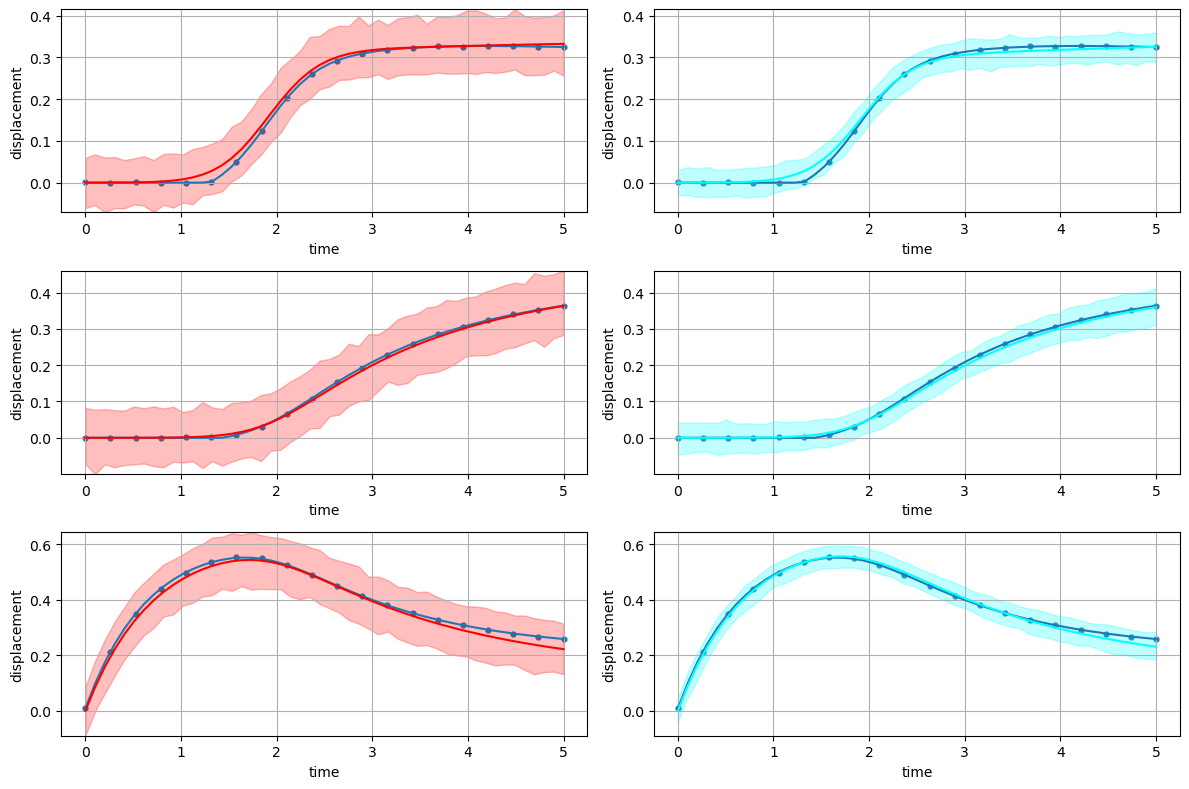

In [28]:
###############################
# Plot is without discrepancy added
plt.figure(figsize=(12, 8))
for iii in range(J):
    y_upper = np.max((np.max(x_upper_IND_disc[iii,:].detach().numpy().flatten()),np.max(x_upper_MOP_disc[iii,:].detach().numpy().flatten())))
    y_lower = np.min((np.min(x_lower_IND_disc[iii,:].detach().numpy().flatten()),np.min(x_lower_MOP_disc[iii,:].detach().numpy().flatten())))
    
    plt.subplot(J,2,(iii)*2+1)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_IND[iii,:], label="IND mean",color='red')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_IND_disc[iii,:].detach().numpy(),
        x_upper_IND_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='red',
        label="90% posterior band",
    )
    plt.xlabel("time")
    plt.ylabel("displacement")
    # plt.legend()
    plt.ylim((y_lower,y_upper))
    plt.grid()
    plt.tight_layout()

    plt.subplot(J,2,(iii)*2+2)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_MOP[iii,:], label="MOP mean",color='cyan')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_MOP_disc[iii,:].detach().numpy(),
        x_upper_MOP_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='cyan',
        label="90% posterior band",
    )
    plt.xlabel("time")
    plt.ylabel("displacement")
    # plt.legend()
    plt.ylim((y_lower,y_upper))
    plt.tight_layout()
    plt.grid()
plt.show()

In [ ]:
for i in range(J):
    # For forward model evals WITHOUT DISCREPANCY INCLUDED
    IND_metrics = time_dependent_prediction_metrics(
        posterior_state_IND[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )

    MOP_metrics = time_dependent_prediction_metrics(
        posterior_state_MOP[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )
    # For model evals WITH DISCREPANCY ADDED TO OUTPUT
    # IND_metrics = time_dependent_prediction_metrics(
    #     posterior_state_IND_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )

    # MOP_metrics = time_dependent_prediction_metrics(
    #     posterior_state_MOP_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )
    print(f"OUTPUT {i}\n")
    print("Mean RMSE over time:", IND_metrics["mean_rmse_over_time"],MOP_metrics["mean_rmse_over_time"])
    print("Mean bias over time:", IND_metrics["mean_bias_over_time"], MOP_metrics["mean_bias_over_time"])
    print("Mean coverage over time:", IND_metrics["mean_coverage_over_time"], MOP_metrics["mean_coverage_over_time"])
    print("Mean interval width over time:", IND_metrics["mean_interval_width_over_time"], MOP_metrics["mean_interval_width_over_time"])

In [10]:
## Spring Problem
num_par = 5 #leave off discrepancy hyperparameters
J = 2
burnin = 5000
from Run_SIRV_IV_AMwithGibbs_50signals import call_model as call_model_IV
from Run_SIRV_IV_AMwithGibbs_50signals import compute_jacobian as jac_IV

marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.raw_lengthscale.requires_grad = False
target_min_eigval = 1e-6
min_jitter = 1e-10 
gamma_true=1.0

GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(0.1))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False

# Helper function since IRV model gives back all four states, we just need the last three
def IV_only(params,x):
    all_out = call_model_IRV(params,x)
    return all_out[1:4:2,:]



for i in [8]:
    if i<10:
        # fname = 'Fitz_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'SIRV_IV_50signal_results_V2/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'SIRV_IV_50signal_results_V2/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    

    samples_IND = chain_IND_all[0,:,burnin:]
    samples_MOP = chain_MOP_all[0,:,burnin:]
    s2_IND      = s2chain_IND_all[:,burnin:].flatten()
    s2_MOP      = s2chain_MOP_all[:,burnin:].flatten()
    
    num_draws = min(300, samples_IND[0,:].shape[0])
    idx = torch.randint(0, samples_IND[0,:].shape[0], (num_draws,))

    posterior_state_IND = []
    posterior_state_MOP = []
    posterior_state_IND_disc = []
    posterior_state_MOP_disc = []
    disc_IND = []
    disc_MOP = []
    I_MV = torch.eye(n_grid * J)

    GP_Cov_MOP = MultivariateOrthogonalKernel(GP_Cov_unc, num_par=num_par,call_model=IV_only, 
                                               call_jac=jac_IV, gamma=gamma_true, 
                                                    min_jitter=min_jitter)

    for ii in idx:
        states_IND = call_model_IV(samples_IND[:num_par,ii].flatten(),tvals)
        posterior_state_IND.append(states_IND[1:4:2,:])
        states_MOP = call_model_IV(samples_MOP[:num_par,ii].flatten(),tvals)
        posterior_state_MOP.append(states_MOP[1:4:2,:])

        

        ## IND
        GP_Cov_unc.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_IND[num_par+1,ii]]))
        C_x_IND = samples_IND[num_par,ii]*GP_Cov_unc(tvals).evaluate() + s2_IND[ii]*torch.eye(n_grid*J)
        jitter = computeJitter(C_x_IND, target_min_eigval, min_jitter)
        C_x_IND = C_x_IND + jitter*torch.eye(n_grid*J)
        L = torch.linalg.cholesky(C_x_IND + jitter * I_MV)
        temp_IND = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
        disc_IND.append(temp_IND.T)


        ## MOP
        GP_Cov_MOP.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_MOP[num_par+1,ii]]))
        GP_Cov_MOP.gamma = samples_MOP[num_par,ii]
        C_delta_theta_true_xobs_flat = GP_Cov_MOP(tvals, samples_MOP[:num_par,ii].flatten()) + s2_MOP[ii]*torch.eye(n_grid*J)
        jitter = computeJitter(C_delta_theta_true_xobs_flat, target_min_eigval, min_jitter)
        L = torch.linalg.cholesky(C_delta_theta_true_xobs_flat + jitter * I_MV)
        temp_MOP = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
        disc_MOP.append(temp_MOP.T)

        posterior_state_IND_disc.append(states_IND[1:4:2,:]+temp_IND.T+torch.rand((J,n_grid))*s2_IND[ii])
        posterior_state_MOP_disc.append(states_MOP[1:4:2,:]+temp_MOP.T+torch.rand((J,n_grid))*s2_MOP[ii])



    posterior_state_IND = torch.stack(posterior_state_IND)
    posterior_state_MOP = torch.stack(posterior_state_MOP)
    disc_IND = torch.stack(disc_IND)
    disc_MOP = torch.stack(disc_MOP)

    posterior_state_IND_disc = torch.stack(posterior_state_IND_disc)
    posterior_state_MOP_disc = torch.stack(posterior_state_MOP_disc)



    x_mean_IND = posterior_state_IND.mean(dim=0)
    x_lower_IND = posterior_state_IND.quantile(0.05, dim=0)
    x_upper_IND = posterior_state_IND.quantile(0.95, dim=0)

    x_mean_MOP = posterior_state_MOP.mean(dim=0)
    x_lower_MOP = posterior_state_MOP.quantile(0.05, dim=0)
    x_upper_MOP = posterior_state_MOP.quantile(0.95, dim=0)

    x_mean_IND_disc = posterior_state_IND_disc.mean(dim=0)
    x_lower_IND_disc = posterior_state_IND_disc.quantile(0.05, dim=0)
    x_upper_IND_disc = posterior_state_IND_disc.quantile(0.95, dim=0)

    x_mean_MOP_disc = posterior_state_MOP_disc.mean(dim=0)
    x_lower_MOP_disc = posterior_state_MOP_disc.quantile(0.05, dim=0)
    x_upper_MOP_disc = posterior_state_MOP_disc.quantile(0.95, dim=0)


    




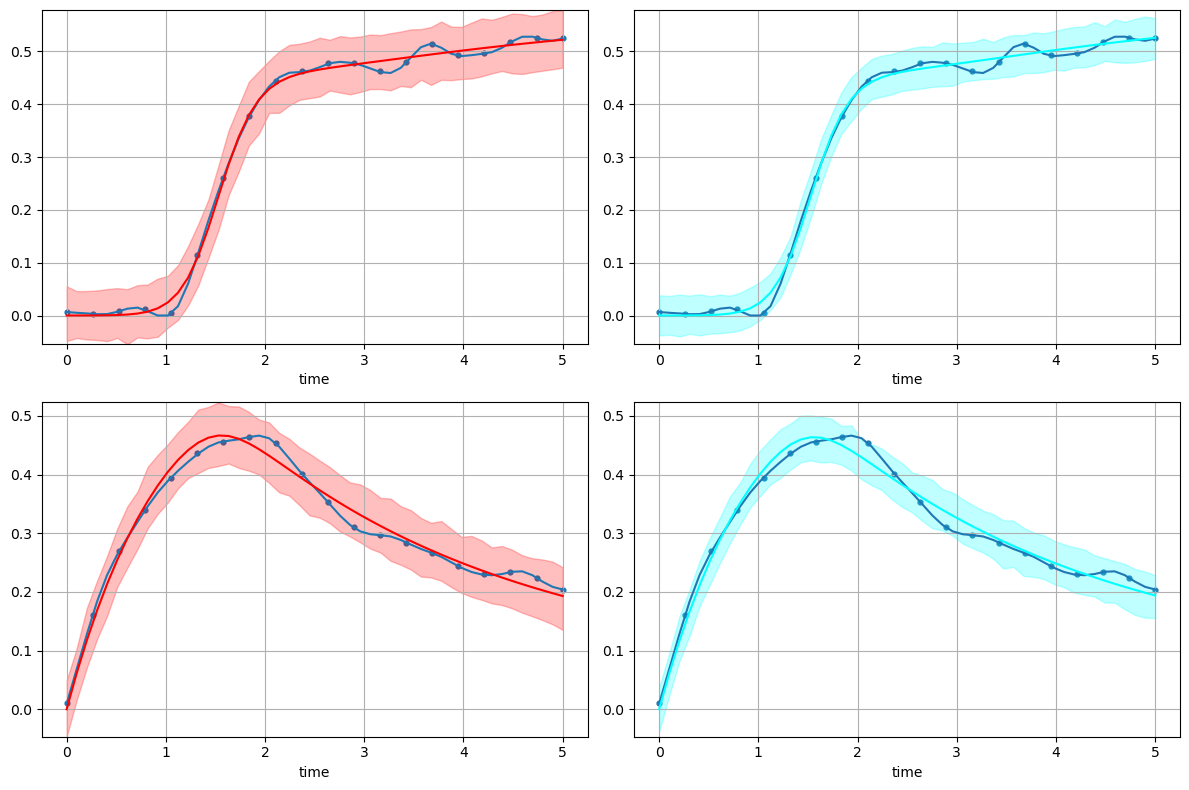

In [20]:
###############################
# Plot is without discrepancy added
plt.figure(figsize=(12, 8))
for iii in range(J):
    y_upper = np.max((np.max(x_upper_IND_disc[iii,:].detach().numpy().flatten()),np.max(x_upper_MOP_disc[iii,:].detach().numpy().flatten())))
    y_lower = np.min((np.min(x_lower_IND_disc[iii,:].detach().numpy().flatten()),np.min(x_lower_MOP_disc[iii,:].detach().numpy().flatten())))

    
    plt.subplot(J,2,(iii)*2+1)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_IND[iii,:], label="IND mean",color='red')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_IND_disc[iii,:].detach().numpy(),
        x_upper_IND_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='red',
        label="90% posterior band",
    )
    plt.xlabel("time")
    plt.ylim((y_lower,y_upper))
    # plt.ylabel("displacement")
    # plt.legend()
    plt.tight_layout()
    plt.grid()

    plt.subplot(J,2,(iii)*2+2)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_MOP[iii,:], label="MOP mean",color='cyan')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_MOP_disc[iii,:].detach().numpy(),
        x_upper_MOP_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='cyan',
        label="90% posterior band",
    )
    plt.xlabel("time")
    plt.ylim((y_lower,y_upper))
    # plt.ylabel("displacement")
    # plt.legend()
    plt.tight_layout()
    plt.grid()
plt.show()

In [ ]:
for i in range(J):
    # For forward model evals WITHOUT DISCREPANCY INCLUDED
    IND_metrics = time_dependent_prediction_metrics(
        posterior_state_IND[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )

    MOP_metrics = time_dependent_prediction_metrics(
        posterior_state_MOP[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )
    # For model evals WITH DISCREPANCY ADDED TO OUTPUT
    # IND_metrics = time_dependent_prediction_metrics(
    #     posterior_state_IND_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )

    # MOP_metrics = time_dependent_prediction_metrics(
    #     posterior_state_MOP_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )
    print(f"OUTPUT {i}\n")
    print("Mean RMSE over time:", IND_metrics["mean_rmse_over_time"],MOP_metrics["mean_rmse_over_time"])
    print("Mean bias over time:", IND_metrics["mean_bias_over_time"], MOP_metrics["mean_bias_over_time"])
    print("Mean coverage over time:", IND_metrics["mean_coverage_over_time"], MOP_metrics["mean_coverage_over_time"])
    print("Mean interval width over time:", IND_metrics["mean_interval_width_over_time"], MOP_metrics["mean_interval_width_over_time"])

In [38]:
## Spring Problem
num_par = 4 #leave off discrepancy hyperparameters
J = 2
burnin = 5000
from Run_Fitz_AMwithGibbs_50signals import call_model as call_model_Fitz
from Run_Fitz_AMwithGibbs_50signals import compute_jacobian as jac_Fitz

marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.raw_lengthscale.requires_grad = False
target_min_eigval = 1e-6
min_jitter = 1e-10 
gamma_true=1.0

GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(0.1))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False

# Helper function since IRV model gives back all four states, we just need the last three


for i in [16]:
    if i<10:
        fname = 'Fitz_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        fname = 'Fitz_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    

    samples_IND = chain_IND_all[0,:,burnin:]
    samples_MOP = chain_MOP_all[0,:,burnin:]
    s2_IND      = s2chain_IND_all[:,burnin:].flatten()
    s2_MOP      = s2chain_MOP_all[:,burnin:].flatten()
    
    num_draws = min(300, samples_IND[0,:].shape[0])
    idx = torch.randint(0, samples_IND[0,:].shape[0], (num_draws,))

    posterior_state_IND = []
    posterior_state_MOP = []
    posterior_state_IND_disc = []
    posterior_state_MOP_disc = []
    disc_IND = []
    disc_MOP = []
    I_MV = torch.eye(n_grid * J)

    GP_Cov_MOP = MultivariateOrthogonalKernel(GP_Cov_unc, num_par=num_par,call_model=call_model_Fitz, 
                                               call_jac=jac_Fitz, gamma=gamma_true, 
                                                    min_jitter=min_jitter)

    for ii in idx:
        states_IND = call_model_Fitz(samples_IND[:num_par,ii].flatten(),tvals)
        posterior_state_IND.append(states_IND[0:J,:])
        states_MOP = call_model_Fitz(samples_MOP[:num_par,ii].flatten(),tvals)
        posterior_state_MOP.append(states_MOP[0:J,:])

        

        ## IND
        GP_Cov_unc.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_IND[num_par+1,ii]]))
        C_x_IND = samples_IND[num_par,ii]*GP_Cov_unc(tvals).evaluate() + s2_IND[ii]*torch.eye(n_grid*J)
        jitter = computeJitter(C_x_IND, target_min_eigval, min_jitter)
        C_x_IND = C_x_IND + jitter*torch.eye(n_grid*J)
        L = torch.linalg.cholesky(C_x_IND + jitter * I_MV)
        temp_IND = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
        disc_IND.append(temp_IND.T)


        ## MOP
        GP_Cov_MOP.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_MOP[num_par+1,ii]]))
        GP_Cov_MOP.gamma = samples_MOP[num_par,ii]
        C_delta_theta_true_xobs_flat = GP_Cov_MOP(tvals, samples_MOP[:num_par,ii].flatten()) + s2_MOP[ii]*torch.eye(n_grid*J)
        jitter = computeJitter(C_delta_theta_true_xobs_flat, target_min_eigval, min_jitter)
        L = torch.linalg.cholesky(C_delta_theta_true_xobs_flat + jitter * I_MV)
        temp_MOP = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
        disc_MOP.append(temp_MOP.T)

        posterior_state_IND_disc.append(states_IND[0:J,:]+temp_IND.T+torch.rand((J,n_grid))*s2_IND[ii])
        posterior_state_MOP_disc.append(states_MOP[0:J,:]+temp_MOP.T+torch.rand((J,n_grid))*s2_MOP[ii])
        



    posterior_state_IND = torch.stack(posterior_state_IND)
    posterior_state_MOP = torch.stack(posterior_state_MOP)
    disc_IND = torch.stack(disc_IND)
    disc_MOP = torch.stack(disc_MOP)

    posterior_state_IND_disc = torch.stack(posterior_state_IND_disc)
    posterior_state_MOP_disc = torch.stack(posterior_state_MOP_disc)



    x_mean_IND = posterior_state_IND.mean(dim=0)
    x_lower_IND = posterior_state_IND.quantile(0.05, dim=0)
    x_upper_IND = posterior_state_IND.quantile(0.95, dim=0)

    x_mean_MOP = posterior_state_MOP.mean(dim=0)
    x_lower_MOP = posterior_state_MOP.quantile(0.05, dim=0)
    x_upper_MOP = posterior_state_MOP.quantile(0.95, dim=0)

    x_mean_IND_disc = posterior_state_IND_disc.mean(dim=0)
    x_lower_IND_disc = posterior_state_IND_disc.quantile(0.05, dim=0)
    x_upper_IND_disc = posterior_state_IND_disc.quantile(0.95, dim=0)

    x_mean_MOP_disc = posterior_state_MOP_disc.mean(dim=0)
    x_lower_MOP_disc = posterior_state_MOP_disc.quantile(0.05, dim=0)
    x_upper_MOP_disc = posterior_state_MOP_disc.quantile(0.95, dim=0)






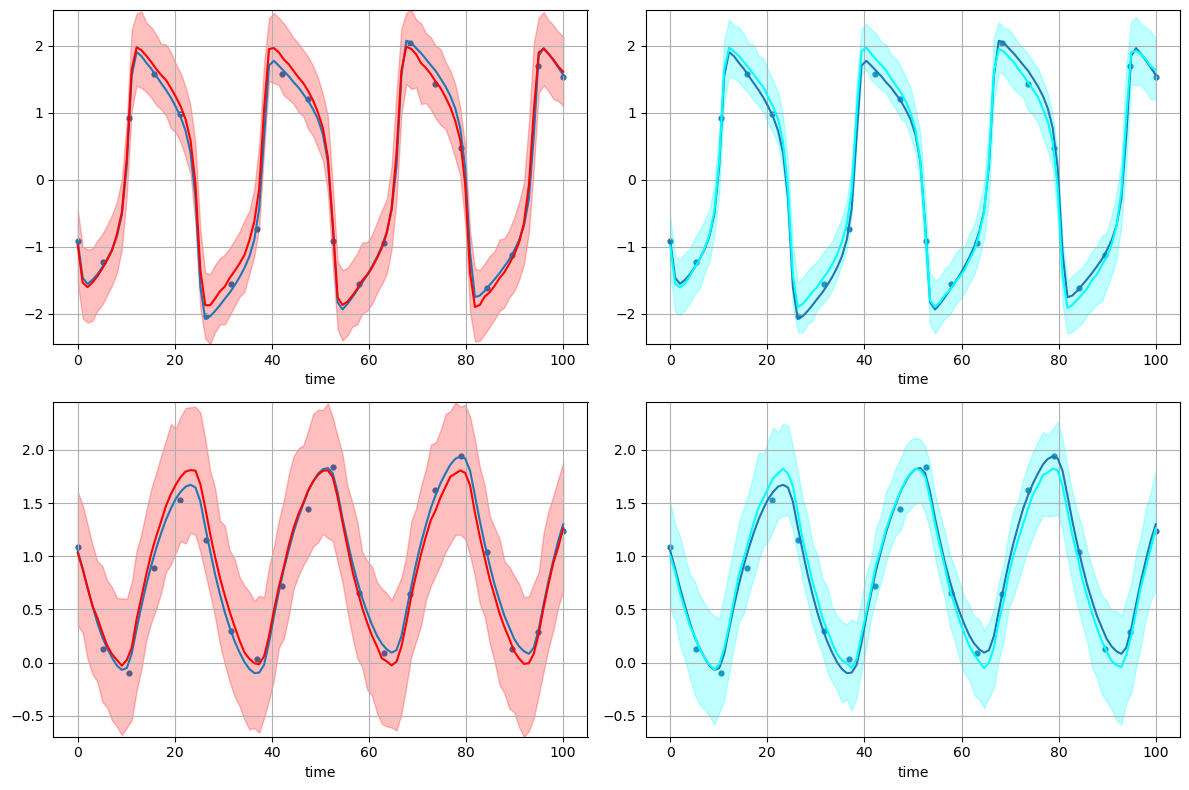

In [39]:
###############################
# Plot is without discrepancy added
plt.figure(figsize=(12, 8))
for iii in range(J):
    y_upper = np.max((np.max(x_upper_IND_disc[iii,:].detach().numpy().flatten()),np.max(x_upper_MOP_disc[iii,:].detach().numpy().flatten())))
    y_lower = np.min((np.min(x_lower_IND_disc[iii,:].detach().numpy().flatten()),np.min(x_lower_MOP_disc[iii,:].detach().numpy().flatten())))
    
    plt.subplot(J,2,(iii)*2+1)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_IND_disc[iii,:], label="IND mean",color='red')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_IND_disc[iii,:].detach().numpy(),
        x_upper_IND_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='red',
        label="90% posterior band",
    )
    plt.xlabel("time")
    # plt.ylabel("displacement")
    # plt.legend()
    plt.ylim((y_lower,y_upper))
    plt.tight_layout()
    plt.grid()

    plt.subplot(J,2,(iii)*2+2)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_MOP_disc[iii,:], label="MOP mean",color='cyan')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_MOP_disc[iii,:].detach().numpy(),
        x_upper_MOP_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='cyan',
        label="90% posterior band",
    )
    plt.xlabel("time")
    # plt.ylabel("displacement")
    # plt.legend()
    plt.ylim((y_lower,y_upper))
    plt.grid()
    plt.tight_layout()
plt.show()

In [ ]:
for i in range(J):
    # For forward model evals WITHOUT DISCREPANCY INCLUDED
    IND_metrics = time_dependent_prediction_metrics(
        posterior_state_IND[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )

    MOP_metrics = time_dependent_prediction_metrics(
        posterior_state_MOP[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )
    # For model evals WITH DISCREPANCY ADDED TO OUTPUT
    # IND_metrics = time_dependent_prediction_metrics(
    #     posterior_state_IND_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )

    # MOP_metrics = time_dependent_prediction_metrics(
    #     posterior_state_MOP_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )
    print(f"OUTPUT {i}\n")
    print("Mean RMSE over time:", IND_metrics["mean_rmse_over_time"],MOP_metrics["mean_rmse_over_time"])
    print("Mean bias over time:", IND_metrics["mean_bias_over_time"], MOP_metrics["mean_bias_over_time"])
    print("Mean coverage over time:", IND_metrics["mean_coverage_over_time"], MOP_metrics["mean_coverage_over_time"])
    print("Mean interval width over time:", IND_metrics["mean_interval_width_over_time"], MOP_metrics["mean_interval_width_over_time"])

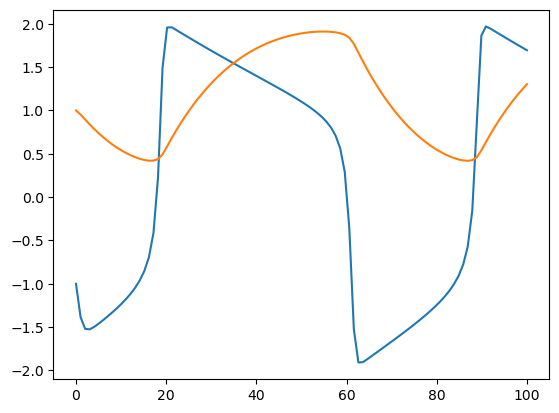

In [81]:
np.set_printoptions(precision=3, suppress=True)

states = call_model_Fitz([1.0,1.0,25,1.2],tvals)
plt.figure()
plt.plot(tvals,states[0:2,:].T)
# plt.plot(tvals,states[:,1])
plt.show()
# print(f"{data_generating_par[:-2]}")